# AG-HYPOPT · Trial 09

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Eight trials are recorded. Best is trial_07 (sw 0.865, h_f 4.0, h_s 3.675, cap 0.107) at 0.0803, then trial_05 (sw 0.844, h_f 3.903, h_s 3.616, cap 0.217) 0.0822, trial_06 (sw 0.497, h_f 4.0, h_s 3.876, cap 0.104) 0.0861, trial_08 (sw 0.869, h_f 3.985, h_s 3.624, cap 0.295) 0.0876. All 0 diverged, gamma finite. The best region: strong sigma weight (0.84-0.87), kernels near their upper bounds (h_f ~3.9-4.0, h_s ~3.6-3.7), and a small gamma cap (~0.1); trial_08 showed a larger cap (0.295) hurts. Phase 'trials'.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_09'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (8/5 trials)
ID |     ei | params
 1 | 3.9919 | {"gamma_rel_cap": 0.23092007808116063, "h_f_scale": 4.0, "h_s_scale": 3.603032821431027, "sigma_weight": 0.8468371632421319}
 2 | 3.6903 | {"gamma_rel_cap": 0.21862400006475435, "h_f_scale": 4.0, "h_s_scale": 3.364830388642214, "sigma_weight": 0.8471159997101114}
 3 | 0.7028 | {"gamma_rel_cap": 0.3526668522947269, "h_f_scale": 3.0278068107840577, "h_s_scale": 3.184715932480493, "sigma_weight": 0.8685672885675162}
 4 | 3.9792 | {"gamma_rel_cap": 0.19615050828440223, "h_f_scale": 3.8598121441812943, "h_s_scale": 3.5819822090456443, "sigma_weight": 0.8541639888656112}
 5 | 0.1879 | {"gamma_rel_cap": 0.07484914374048263, "h_f_scale": 0.4834506153124878, "h_s_scale": 3.86043094343936, "sigma_weight": 0.22609832736317137}
 6 | 3.9078 | {"gamma_rel_cap": 0.1649768688609286, "h_f_scale": 3.866106811110541, "h_s_scale": 3.609796067890691, "sigma_weight": 0.18933201942823097}
 7 | 3.6977 | {"gamma_rel_cap": 0.04814177224475202, "h_f

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Best is trial_07 (0.0803) with sw 0.865, h_f 4.0, h_s 3.675, cap 0.107; the batch's high-ei draws are again a tight cluster in that region (ids 1, 4, 6, 2, 7). Inside the region, the gamma cap trend is soft (0.107 best at trial_07, 0.295 worse at trial_08), so the model's top draw is the natural refinement.

Candidate 1 (ei 3.9919, the highest) is essentially the optimum configuration - sw 0.847, h_f 4.0, h_s 3.603 - with a moderately larger gamma cap 0.231, placing it between the best (0.107) and the worse (0.295) caps already sampled. It is the model's best guess and stays inside the optimum region; the alternatives that leave the region (e.g. sharp h_f in id 7, low sw in id 6) were already shown to be inferior.

I choose candidate 1.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1               # candidate 1: sigma_weight 0.847, h_f_scale 4.0, h_s_scale 3.603, gamma_rel_cap 0.231 (top ei, optimum region)


chosen: {'gamma_rel_cap': 0.23092007808116063, 'h_f_scale': 4.0, 'h_s_scale': 3.603032821431027, 'sigma_weight': 0.8468371632421319}
Running  1nW Trans05 ... 

μ 9.39 -> 6.02 | γ 8.5 -> 4.27 | NLL 0.25


Running  1nW Trans20 ... 

μ 17.32 -> 27.58 | γ 8.5 -> 5.41 | NLL 0.65


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 67.97 | γ 14.1 -> 13.91 | NLL 0.72


Running 3nW Trans100 ... 

μ 175.71 -> 98.15 | γ 14.1 -> 14.01 | NLL 0.67



Total: 7.7 min


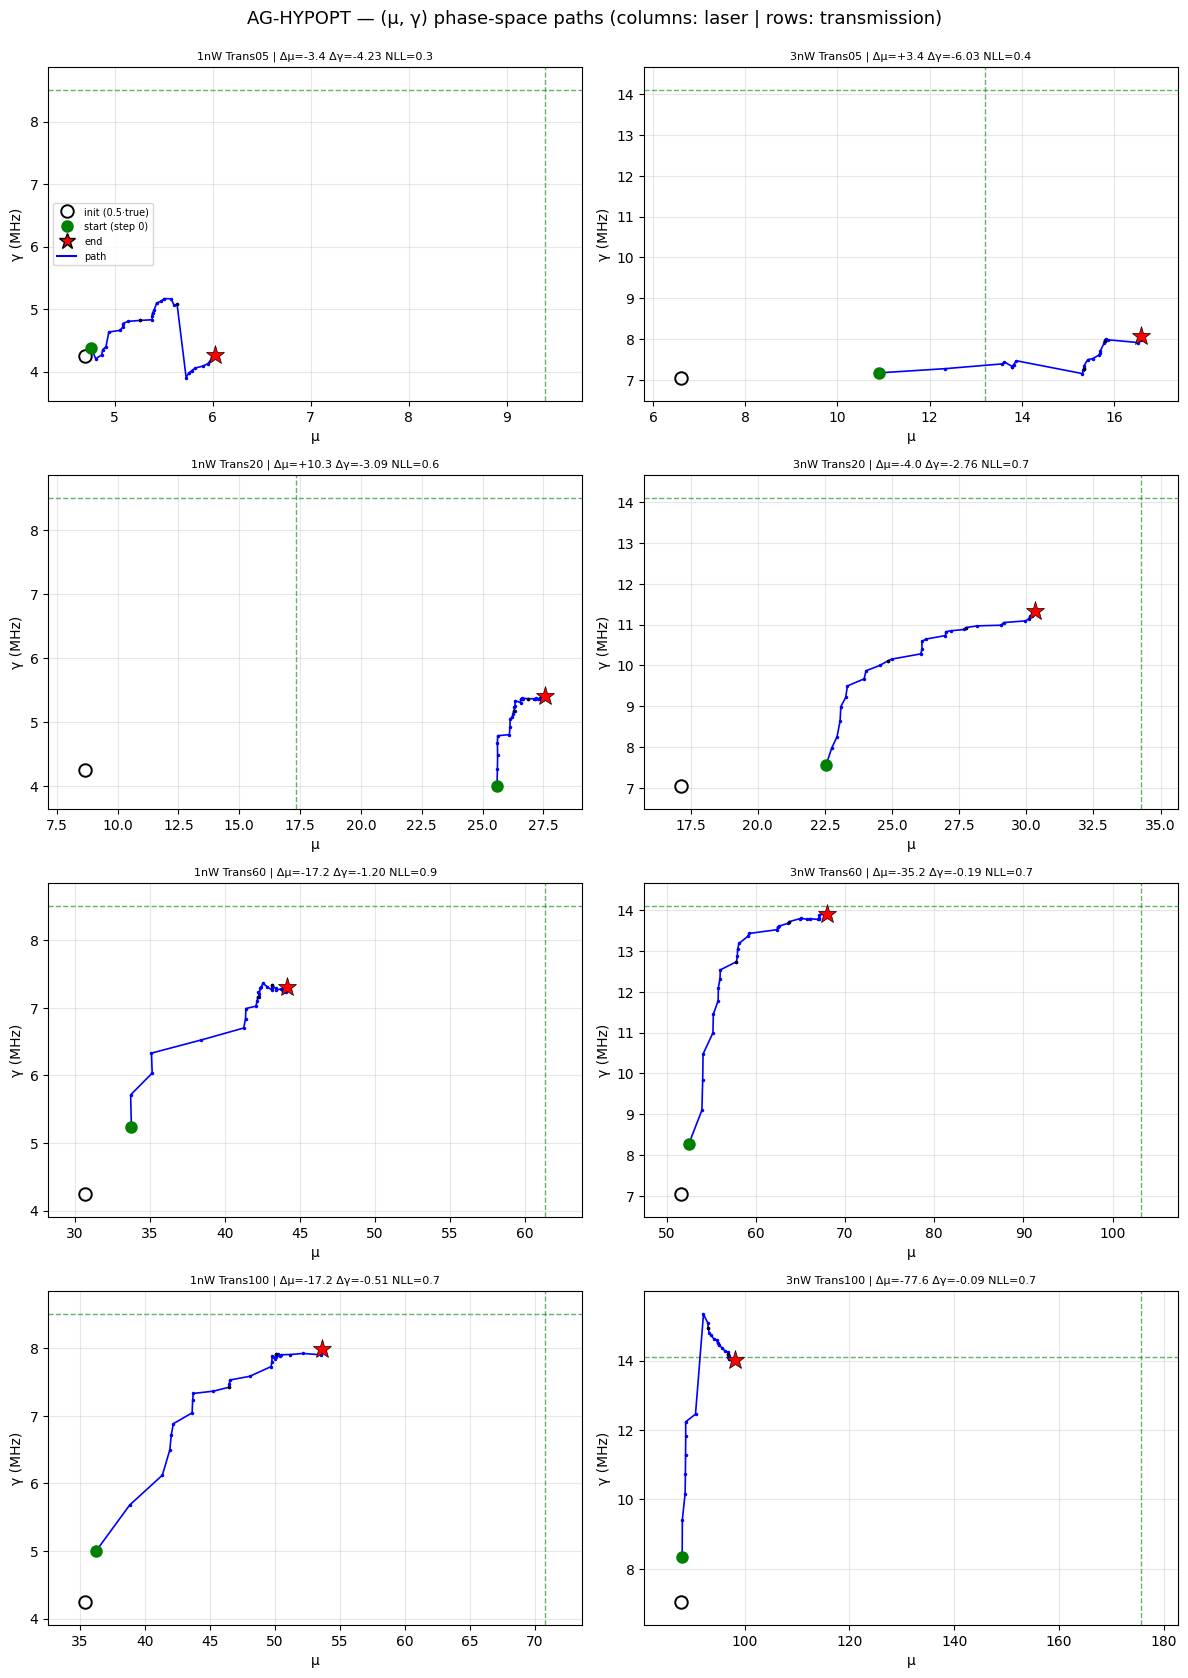

trial finished in 7.7 min
objective = 0.0839 ± 0.0252
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    6.02   -35.9 |     8.50    4.27   -49.7
1nW Trans20       17.32   27.58   +59.3 |     8.50    5.41   -36.3
1nW Trans60       61.37   44.15   -28.1 |     8.50    7.30   -14.1
1nW Trans100       70.82   53.66   -24.2 |     8.50    7.99    -6.0
3nW Trans05       13.20   16.58   +25.6 |    14.10    8.07   -42.8
3nW Trans20       34.28   30.31   -11.6 |    14.10   11.34   -19.6
3nW Trans60      103.20   67.97   -34.1 |    14.10   13.91    -1.3
3nW Trans100      175.71   98.15   -44.1 |    14.10   14.01    -0.7

weighted objective (T-graded, cap=1.0) = 0.0839 | diverged cells: 0
μ: RMSE 31.605 (rel 35.5%, bias -17.609) | γ: RMSE 3.024 (rel 27.9%, bias -2.262)


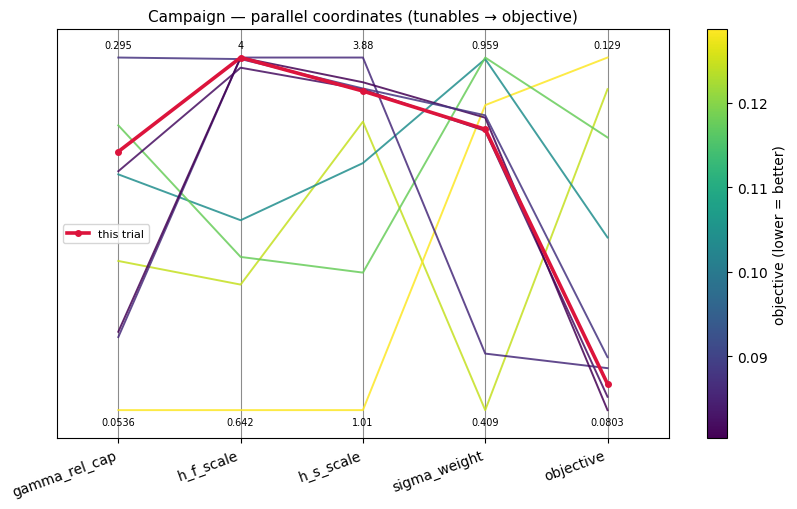

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 09 (sw 0.847, h_f 4.0, h_s 3.603, cap 0.231) ran to completion in 7.7 min with 0 diverged cells and gamma finite on all 8 cells; objective 0.0839 +/- 0.0252 - third best, above trial_07 (0.0803) and trial_05 (0.0822), below trial_06 (0.0861) and trial_08 (0.0876).

mu rel-RMSE 35.5%, among the best (trial_06 34.0%, trial_07 35.9%): same shape - high-T undershoot (3nW Trans100 -44.1%, 3nW Trans60 -34.1%, 1nW Trans60 -28.1%, 1nW Trans100 -24.2%) and low-T overshoot (1nW Trans20 +59.3%, 3nW Trans05 +25.6%); bias -17.61.

gamma rel-RMSE 27.9% is worse than trial_07's 22.3%, driven by low T (1nW Trans05 -49.7%, 3nW Trans05 -42.8%, 1nW Trans20 -36.3%), while high T is near truth (-0.7%, -1.3%).

The candidate was the model's top draw and again a near-copy of trial_07 (sw 0.847 vs 0.865, h_f 4.0, h_s 3.60 vs 3.68) but with a larger gamma cap (0.231 vs 0.107). As in trial_08, the larger gamma cap left mu fine but degraded gamma, so the cap effect is consistent across both tests.

**Summary:** Trial 09 (sw=0.847, h_f=4.0, h_s=3.603, cap=0.231) finished in 7.7 min with 0 diverged cells and gamma finite, objective 0.0839 +/- 0.0252 - third best, above trial_07 and trial_05 (mu rel-RMSE 35.5%, gamma rel-RMSE 27.9%).
**Key insight:** A larger gamma cap (0.231) again raised the gamma error (27.9% vs trial_07's 22.3% at cap 0.107), reinforcing that a small gamma trust region is best in the optimum region.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar: none (no structural-change proposals).


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 09 (sw=0.847, h_f=4.0, h_s=3.603, cap=0.231): objective 0.0839 +/- 0.0252 - third best; 0 diverged cells, gamma finite (mu rel-RMSE 35.5%, gamma rel-RMSE 27.9%).'
KEY_INSIGHT = 'A larger gamma cap (0.231) again raised the gamma error (27.9% vs trial_07 22.3% at cap 0.107), reinforcing that a small gamma trust region is best in the optimum region.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_09 | current best: trial_07


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_10.ipynb. Open it and follow its cells from the top.
